In [36]:
# Import necessary libraries for data manipulation, machine learning, and visualization
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np


In [37]:
# Load data files
attempts = pd.read_csv("attempts_at_goal_team.csv")
fifa_stats = pd.read_csv("FIFA_Site_Team_Stats.csv")
rounds2026 = pd.read_csv("rounds2026.csv")


# Inspect data structure and quality
attempts.info()
fifa_stats.info()
rounds2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rank                              48 non-null     int64  
 1   team_id                           48 non-null     int64  
 2   team                              48 non-null     str    
 3   team_abbrv                        48 non-null     str    
 4   goals                             48 non-null     int64  
 5   assists                           48 non-null     int64  
 6   attempt_at_goal                   48 non-null     int64  
 7   attempt_ontarget                  48 non-null     int64  
 8   offtarget_attempt                 48 non-null     int64  
 9   attempt_goal_convRate_percentage  48 non-null     int64  
 10  attempt_inside_pa                 48 non-null     int64  
 11  attempt_outside_pa                48 non-null     int64  
 12  headed_attempt_goal  

In [38]:
# Standardise column names for consistency
attempts_renamed = attempts.rename(columns={
    "team": "Team",
    "team_abbrv": "TeamAbbr",
    "goals": "Goals",
    "assists": "Assists",
    "attempt_at_goal": "Attempts_at_goal",
    "attempt_ontarget": "Attempts_on_target",
    "offtarget_attempt": "Off_Target_Attempts",
    "attempt_goal_convRate_percentage": "Attempts_at_goal_conversionrate(%)",
    "attempt_inside_pa": "Attempts_Inside_PenaltyArea",
    "attempt_outside_pa": "Attemps_Outside_PenaltyArea",
    "headed_attempt_goal": "Headed_Attemps_at_Goal",
    "xG": "xG",
    "xG_efficiency": "xG_Efficiency",
    "corners": "Corners",
    "possession_control_percentage": "Possession_Control(%)"
})

# Create a copy of the renamed attempts dataframe for further analysis
team_stats = attempts_renamed.copy()

In [39]:
# Keep only matches with complete score data
matches = rounds2026.dropna(subset=["homeScore", "awayScore"].copy())

matches.head()
matches.info()

# Print the number of matches with complete score data
print("Number of matches with scores: ", len(matches))

# Calculate the goal difference for each match
matches_len = len(matches)
matches["goal_diff"] = matches["homeScore"] - matches["awayScore"]


<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [40]:
# Merge match data with home team statistics
home = matches.merge(
    team_stats,
    left_on="homeSquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_home")
)


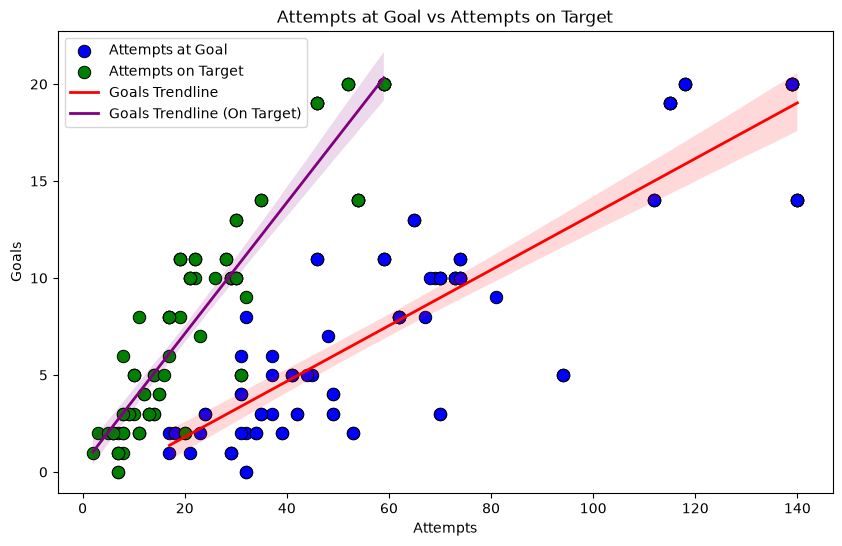

In [41]:
# Visualize shooting accuracy: attempts vs goals scored
plt.figure(figsize=(10, 6))
# Scatter plot of attempts at goal vs goals scored adding blue color for attempts at goal
sns.scatterplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    color="blue",
    s=80,
    edgecolor="black",
    label="Attempts at Goal"
)
# Scatter plot of attempts on target vs goals scored adding green color for attempts on target
sns.scatterplot(
    x=home["Attempts_on_target"],
    y=home["Goals"],
    color="green",
    s=80,
    edgecolor="black",
    label="Attempts on Target"
)
# Add a regression trendline for attempts at goal vs goals scored in red
sns.regplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    scatter=False,
    line_kws={"color": "red", "linewidth": 2},
    label="Goals Trendline"
)
# Add a regression trendline for attempts on target vs goals scored in purple
sns.regplot(
    x=home["Attempts_on_target"],
    y=home["Goals"],
    scatter=False,
    line_kws={"color": "purple", "linewidth": 2},
    label="Goals Trendline (On Target)"
)
# add labels and title for the plot
plt.xlabel("Attempts")
plt.ylabel("Goals")
plt.title("Attempts at Goal vs Attempts on Target")
plt.legend()
plt.show()


In [42]:
# Prefix home team columns to distinguish from away team
home_cols_map = {
    "Goals": "home_Goals",
    "Attempts_at_goal": "home_Attempts_at_goal",
    "Attempts_on_target": "home_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "home_ConversionRate",
    "Attempts_Inside_PenaltyArea": "home_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "home_Headed_attempts",
    "xG": "home_xG",
    "Possession_Control(%)": "home_Possession",
    "xG_Efficiency_num": "home_xG_eff"
}
home.rename(columns=home_cols_map, inplace=True)



In [43]:
# Merge away team statistics to create full match dataset
full = home.merge(
    team_stats,
    left_on="awaySquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_away")
)



In [44]:
# Prefix away team columns
away_cols_map = {
    "Goals": "away_Goals",
    "Attempts_at_goal": "away_Attempts_at_goal",
    "Attempts_on_target": "away_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "away_ConversionRate",
    "Attempts_Inside_PenaltyArea": "away_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "away_Headed_attempts",
    "xG": "away_xG",
    "Possession_Control(%)": "away_Possession",
    "xG_Efficiency_num": "away_xG_eff"
}
full.rename(columns=away_cols_map, inplace=True)



In [45]:
# Create difference features (home minus away) to capture home team advantage
full["diff_goals_scored"] = full["home_Goals"] - full["away_Goals"]
full["diff_attempts_at_goal"] = full["home_Attempts_at_goal"] - full["away_Attempts_at_goal"]
full["diff_attempts_on_target"] = full["home_Attempts_on_target"] - full["away_Attempts_on_target"]
full["diff_conversion_rate"] = full["home_ConversionRate"] - full["away_ConversionRate"]
full["diff_attempts_inside_pa"] = full["home_Attempts_inside_PA"] - full["away_Attempts_inside_PA"]
full["diff_headed_attempts"] = full["home_Headed_attempts"] - full["away_Headed_attempts"]
full["diff_xG"] = full["home_xG"] - full["away_xG"]
full["diff_possession"] = full["home_Possession"] - full["away_Possession"]

In [46]:
feature_cols = [
    "diff_goals_scored",
    "diff_attempts_at_goal",
    "diff_attempts_on_target",
    "diff_conversion_rate",
    "diff_attempts_inside_pa",
    "diff_headed_attempts",
    "diff_xG",
    "diff_possession"
]

In [47]:
# Display the first few rows of the full dataset and its information
full.info()
full.head()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 68 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                104 non-null    int64  
 1   voteStatus                        104 non-null    str    
 2   stage                             104 non-null    str    
 3   roundName                         104 non-null    str    
 4   votingStartDate                   104 non-null    str    
 5   votingEndDate                     104 non-null    str    
 6   votingOpenedAt                    104 non-null    str    
 7   selectedFormation                 2 non-null      str    
 8   winners                           104 non-null    str    
 9   formations                        2 non-null      str    
 10  id.1                              104 non-null    int64  
 11  venueName                         104 non-null    str    
 12  venueCity          

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Corners_away,away_Possession,diff_goals_scored,diff_attempts_at_goal,diff_attempts_on_target,diff_conversion_rate,diff_attempts_inside_pa,diff_headed_attempts,diff_xG,diff_possession
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,46,8,31,10,9,31,8,5.62,2
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,37,0,-2,3,0,-1,-1,0.94,19
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,40,0,57,17,-9,39,8,5.28,13
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,10,27,8,24,11,10,30,8,4.38,25
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,28,49,-8,-57,-24,-2,-40,-5,-7.71,-18


In [48]:
# Separate the explanatory variable (x) from the response variable (y)
x1 = full[['diff_attempts_at_goal']].values  # explanatory variable (x)
y1 = full['diff_goals_scored'].values  # response variable (y)

# Create the second set of explanatory and response variables for model 2
x2 = full[["home_Goals"]].values - full[["away_Goals"]].values
y2 = full[["home_Attempts_at_goal"]].values - full[["away_Attempts_at_goal"]].values

In [49]:
# sequence of the data is shuffled and split into training and testing sets. 
# 60% of the data is used for training and 40% for testing.
x_train, x_test, y_train, y_test = train_test_split(x1, y1, test_size=0.4)

# Split the second set of explanatory and response variables into training and testing sets. 
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.4)

In [50]:
# build the linear regression model using the training data
model = LinearRegression()
model.fit(x_train, y_train)

print("Intercept (b_0): ", model.intercept_)
print("Coefficient of X (b_1): ", model.coef_)

Intercept (b_0):  0.18061106974005536
Coefficient of X (b_1):  [0.14377024]


In [51]:
# build the linear regression model using the training data 2
model2 = LinearRegression()
model2.fit(x_train2, y_train2)

print("Intercept (b_0): ", model2.intercept_)
print("Coefficient of X (b_1): ", model2.coef_)

Intercept (b_0):  [4.05460417]
Coefficient of X (b_1):  [[5.3175646]]


In [52]:
# use linear regression to predict the values of Y in the test set
y_pred = model.predict(x_test)
df_pred = pd.DataFrame({"Actual": y_test, 
                        "Predicted": y_pred})

print(df_pred)

    Actual  Predicted
0       -2  -2.694794
1      -10  -6.720360
2       10   6.650272
3       -2  -4.420037
4        0  -0.394470
5        3   3.056016
6       -6  -0.538240
7       13  12.257311
8        3   2.193394
9       -9  -2.838564
10      -9  -2.119713
11       7   3.774867
12       6   6.650272
13       6   0.036841
14       0   4.206178
15       1  -2.119713
16      -3  -2.838564
17       5   4.493718
18       4   6.506502
19       8   2.624705
20       3   4.062408
21       4   2.193394
22      -8   3.631097
23       2   3.774867
24       8  15.851567
25     -10 -11.464778
26     -17 -14.771494
27       0   8.375515
28       0  -0.106929
29       3   2.624705
30      -6 -11.033468
31      -4  -4.995118
32       5   4.493718
33       8   5.643880
34      -5  -3.413645
35       2  -0.394470
36       8   2.624705
37       5   8.663055
38      -7  -7.439212
39      14  10.388298
40       8   6.218961
41      -5   3.774867


In [53]:
# use linear regression to predict the values of Y in the test set 2
y_pred2 = model2.predict(x_test2)
df_pred2 = pd.DataFrame({
    "Actual": y_test2.ravel(),
    "Predicted": y_pred2.ravel()
})

print(df_pred2)

    Actual  Predicted
0       70  57.230250
1       41  51.912686
2      -22  25.324863
3       30  30.642427
4      -16   9.372169
5        4   4.054604
6       27  20.007298
7      -44 -59.756171
8      -41 -43.803477
9       47  51.912686
10      34  57.230250
11     -36 -38.485913
12      64  46.595121
13     -36 -17.215654
14      -2   4.054604
15      39  46.595121
16     -25 -22.533219
17      37  30.642427
18     -74 -33.168348
19      -4  14.689733
20      41  14.689733
21      31  46.595121
22     -44 -43.803477
23       7   4.054604
24      57   4.054604
25     -32  -6.580525
26      24  46.595121
27      25 -22.533219
28      45  57.230250
29       6  -1.262960
30      45  35.959992
31     -23 -11.898090
32       3   9.372169
33      -5   4.054604
34      21   4.054604
35      -2  25.324863
36     -53 -33.168348
37      13  -1.262960
38     -55 -11.898090
39      81  78.500509
40      44  25.324863
41     -91 -81.026429


In [54]:
# calculate the mean absolute error (MAE), mean squared error (MSE) and root mean squared error (RMSE)
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)

print("Mean Absolute Error (MAE): ", mae)
print("Mean Squared Error (MSE): ", mse)
print("Root Mean Squared Error (RMSE): ", rmse)

Mean Absolute Error (MAE):  3.07514235904084
Mean Squared Error (MSE):  16.953928714191306
Root Mean Squared Error (RMSE):  4.11751487115606


In [55]:
# calculate the mean absolute error (MAE), mean squared error (MSE) and root mean squared error (RMSE) set 2
mae2 = metrics.mean_absolute_error(y_test2, y_pred2)
mse2 = metrics.mean_squared_error(y_test2, y_pred2)
rmse2 = math.sqrt(mse2)

print("Mean Absolute Error (MAE)2: ", mae2)
print("Mean Squared Error (MSE)2: ", mse2)
print("Root Mean Squared Error (RMSE)2: ", rmse2)

Mean Absolute Error (MAE)2:  16.015709180301357
Mean Squared Error (MSE)2:  440.2434258798887
Root Mean Squared Error (RMSE)2:  20.981978597832207


In [56]:
# Normalize RMSE
y_max = y_test.max()
y_min = y_test.min()
nrmse = rmse / (y_max - y_min)
print("Normalized Root Mean Squared Error (NRMSE): ", nrmse)

Normalized Root Mean Squared Error (NRMSE):  0.1328230603598729


In [57]:
# Normalize RMSE 2
y_max2 = y_test2.max()
y_min2 = y_test2.min()
nrmse2 = rmse2 / (y_max2 - y_min2)
print("Normalized Root Mean Squared Error (NRMSE)2: ", nrmse2)

Normalized Root Mean Squared Error (NRMSE)2:  0.12198824766181515


In [58]:
# construct a baseline model that takes the average of Y in training set as the basis of the prediction
y_base = np.mean(y_train)

# make prediction for every y value in the test set
y_pred_base = [y_base] * len(y_test)

# compare the baseline prediction with the actual values of Y in the test set
df_base_pred = pd.DataFrame({"Actual": y_test,
                             "Predicted": y_pred_base})

print(df_base_pred)

    Actual  Predicted
0       -2   1.854839
1      -10   1.854839
2       10   1.854839
3       -2   1.854839
4        0   1.854839
5        3   1.854839
6       -6   1.854839
7       13   1.854839
8        3   1.854839
9       -9   1.854839
10      -9   1.854839
11       7   1.854839
12       6   1.854839
13       6   1.854839
14       0   1.854839
15       1   1.854839
16      -3   1.854839
17       5   1.854839
18       4   1.854839
19       8   1.854839
20       3   1.854839
21       4   1.854839
22      -8   1.854839
23       2   1.854839
24       8   1.854839
25     -10   1.854839
26     -17   1.854839
27       0   1.854839
28       0   1.854839
29       3   1.854839
30      -6   1.854839
31      -4   1.854839
32       5   1.854839
33       8   1.854839
34      -5   1.854839
35       2   1.854839
36       8   1.854839
37       5   1.854839
38      -7   1.854839
39      14   1.854839
40       8   1.854839
41      -5   1.854839


In [59]:
# construct a baseline model that takes the average of Y in training set as the basis of the prediction set 2
y_base2 = np.mean(y_train2)

# make prediction for every y value in the test set 2
y_pred_base2 = [y_base2] * len(y_test2)

# compare the baseline prediction with the actual values of Y in the test set 2
df_base_pred2 = pd.DataFrame({
    "Actual": np.asarray(y_test2).ravel(),
    "Predicted": np.asarray(y_pred_base2).ravel()
})

print(df_base_pred2)

    Actual  Predicted
0       70  13.403226
1       41  13.403226
2      -22  13.403226
3       30  13.403226
4      -16  13.403226
5        4  13.403226
6       27  13.403226
7      -44  13.403226
8      -41  13.403226
9       47  13.403226
10      34  13.403226
11     -36  13.403226
12      64  13.403226
13     -36  13.403226
14      -2  13.403226
15      39  13.403226
16     -25  13.403226
17      37  13.403226
18     -74  13.403226
19      -4  13.403226
20      41  13.403226
21      31  13.403226
22     -44  13.403226
23       7  13.403226
24      57  13.403226
25     -32  13.403226
26      24  13.403226
27      25  13.403226
28      45  13.403226
29       6  13.403226
30      45  13.403226
31     -23  13.403226
32       3  13.403226
33      -5  13.403226
34      21  13.403226
35      -2  13.403226
36     -53  13.403226
37      13  13.403226
38     -55  13.403226
39      81  13.403226
40      44  13.403226
41     -91  13.403226


In [60]:
# calculate the error metrics for the baseline model
mae = metrics.mean_absolute_error(y_test, y_pred_base)
mse = metrics.mean_squared_error(y_test, y_pred_base)
rmse = math.sqrt(mse)
# Normalize RMSE
y_max = y_test.max()
y_min = y_test.min()
nrmse = rmse / (y_max - y_min)
# print the error metrics for the baseline model
print("MAE of baseline model: ", mae)
print("MSE of baseline model: ", mse)
print("RMSE of baseline model: ", rmse)
print("NRMSE of baseline model: ", nrmse)

MAE of baseline model:  5.5545314900153615
MSE of baseline model:  47.597108666567564
RMSE of baseline model:  6.899065782159753
NRMSE of baseline model:  0.22255050910192753


In [61]:
# calculate the error metrics for the baseline model 2
mae2 = metrics.mean_absolute_error(y_test2, y_pred_base2)
mse2 = metrics.mean_squared_error(y_test2, y_pred_base2)
rmse2 = math.sqrt(mse2)
# Normalize RMSE 2
y_max2 = y_test2.max()
y_min2 = y_test2.min()
nrmse2 = rmse2 / (y_max2 - y_min2)
# print the error metrics for the baseline model 2
print("MAE of baseline model 2: ", mae2)
print("MSE of baseline model 2: ", mse2)
print("RMSE of baseline model 2: ", rmse2)
print("NRMSE of baseline model 2: ", nrmse2)

MAE of baseline model 2:  34.01459293394777
MSE of baseline model 2:  1689.901454338239
RMSE of baseline model 2:  41.10841099262095
NRMSE of baseline model 2:  0.2390023894919823


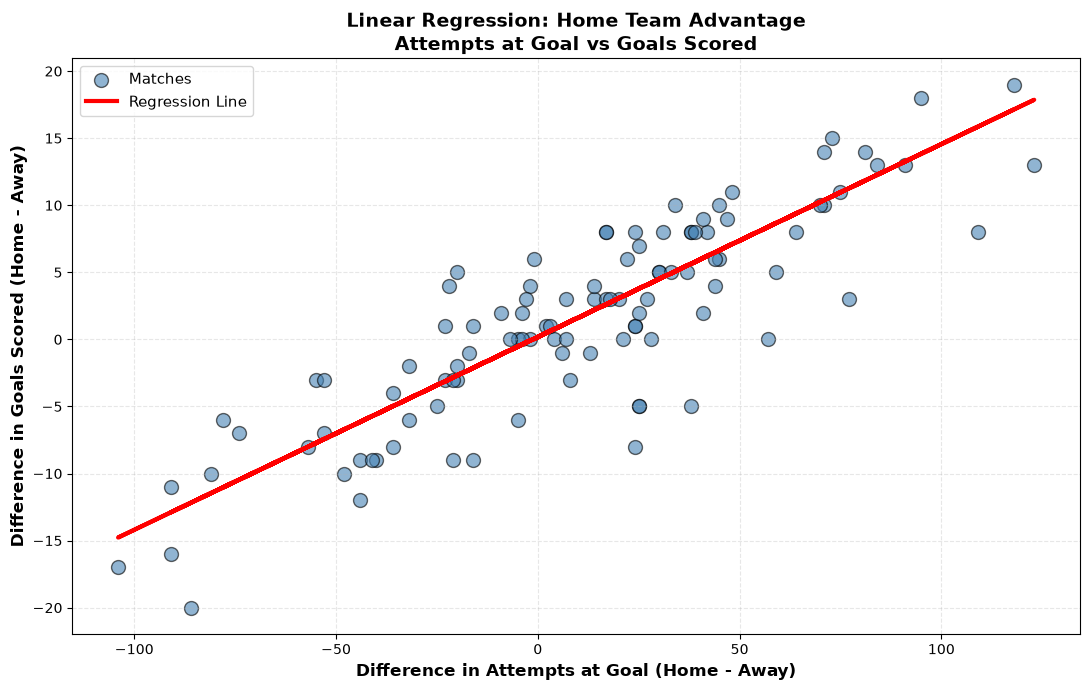

In [62]:
# Main visualization: Scatter plot with fitted regression line
plt.figure(figsize=(11, 7))
plt.scatter(x1, y1, alpha=0.6, s=100, color='steelblue', edgecolor='black', label='Matches')
plt.plot(x1, model.predict(x1), color='red', linewidth=3, label='Regression Line')

plt.xlabel('Difference in Attempts at Goal (Home - Away)', fontsize=12, fontweight='bold')
plt.ylabel('Difference in Goals Scored (Home - Away)', fontsize=12, fontweight='bold')
plt.title('Linear Regression: Home Team Advantage\nAttempts at Goal vs Goals Scored', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

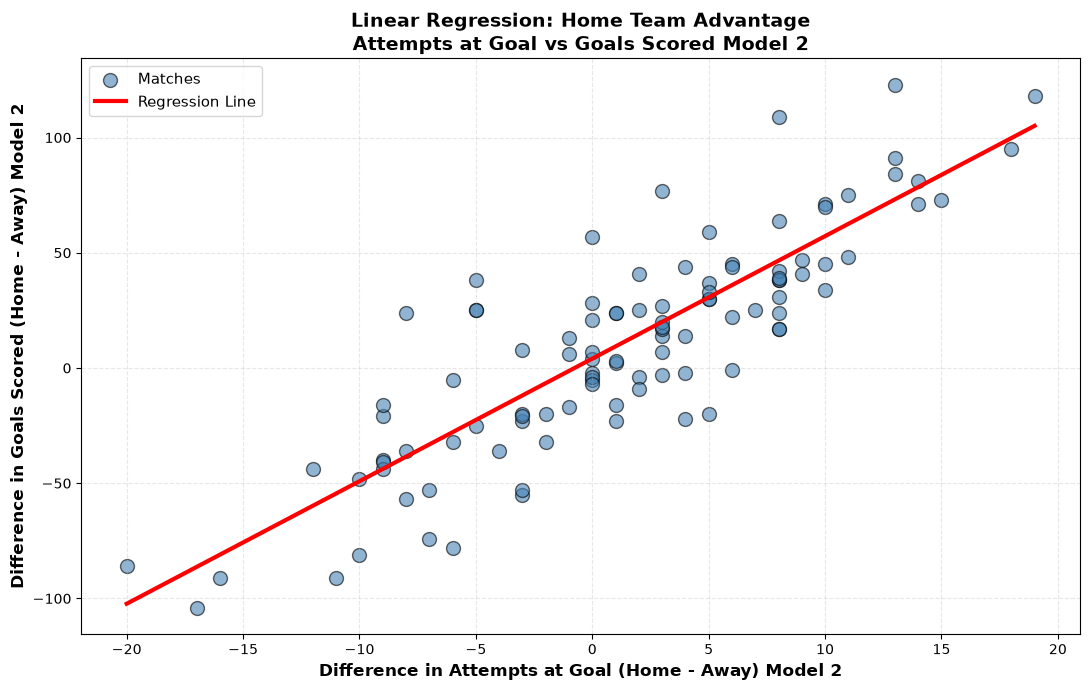

In [63]:
# Main visualization 2: Scatter plot model 2 with fitted regression line model 2
plt.figure(figsize=(11, 7))
plt.scatter(x2, y2, alpha=0.6, s=100, color='steelblue', edgecolor='black', label='Matches')
# Use model2 and reshape x2 into a 2-dimensional array
x2_values = np.asarray(x2).ravel()
sort_idx = np.argsort(x2_values)

plt.plot(
    x2_values[sort_idx],
    model2.predict(x2_values.reshape(-1, 1))[sort_idx],
    color='red',
    linewidth=3,
    label='Regression Line'
)

plt.xlabel('Difference in Attempts at Goal (Home - Away) Model 2', fontsize=12, fontweight='bold')
plt.ylabel('Difference in Goals Scored (Home - Away) Model 2', fontsize=12, fontweight='bold')
plt.title('Linear Regression: Home Team Advantage\nAttempts at Goal vs Goals Scored Model 2', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

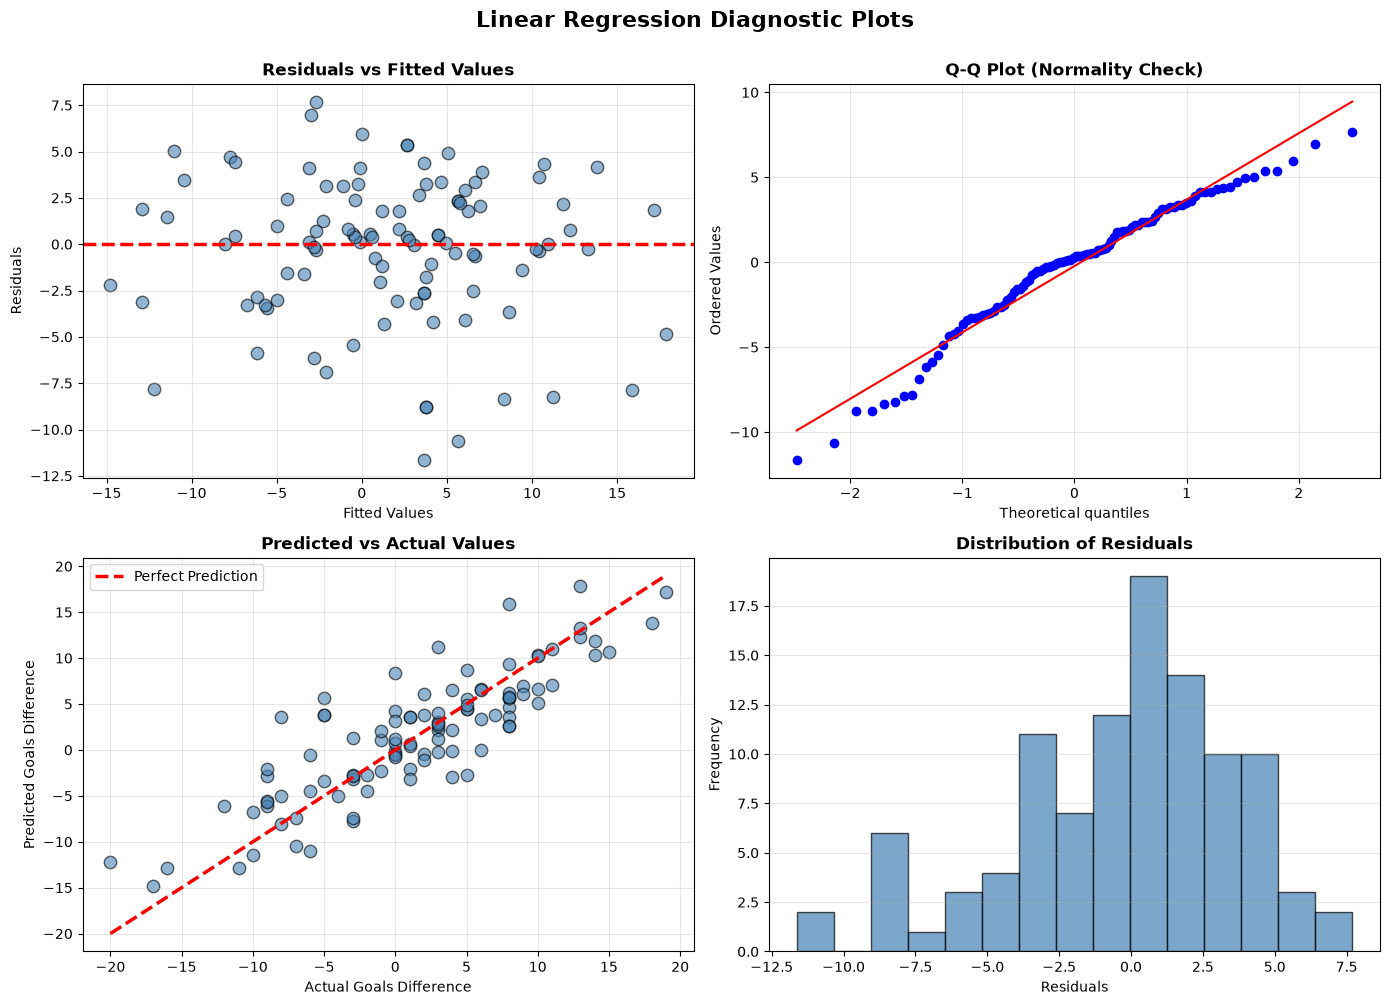


LINEAR REGRESSION MODEL SUMMARY
Intercept (b₀): 0.1806
Slope (b₁): 0.1438

R² Score (Training): 0.7783
R² Score (Testing): 0.6350
R² Score (Full Data): 0.7323

Interpretation:
For every additional attempt at goal (home vs away),
the home team scores 0.1438 more goals on average.


In [64]:
# Diagnostic plots to validate model assumptions
from scipy import stats

# Calculate predictions and residuals on full dataset
y_pred_full = model.predict(x1)
residuals = y1 - y_pred_full.flatten()

# Create 2x2 subplot for diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Diagnostic Plots', fontsize=16, fontweight='bold', y=1.00)

# 1. Residuals vs Fitted Values
axes[0, 0].scatter(y_pred_full, residuals, alpha=0.6, s=80, edgecolor='black', color='steelblue')
axes[0, 0].axhline(0, color='red', linewidth=2.5, linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (Normality of Residuals)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Predicted vs Actual
axes[1, 0].scatter(y1, y_pred_full, alpha=0.6, s=80, edgecolor='black', color='steelblue')
axes[1, 0].plot([y1.min(), y1.max()], [y1.min(), y1.max()], 'r--', linewidth=2.5, label='Perfect Prediction')
axes[1, 0].set_title('Predicted vs Actual Values', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Actual Goals Difference')
axes[1, 0].set_ylabel('Predicted Goals Difference')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Histogram of Residuals
axes[1, 1].hist(residuals, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print model statistics
print("\n" + "="*60)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*60)
print(f"Intercept (b₀): {model.intercept_:.4f}")
print(f"Slope (b₁): {model.coef_[0]:.4f}")
print(f"\nR² Score (Training): {model.score(x_train, y_train):.4f}")
print(f"R² Score (Testing): {model.score(x_test, y_test):.4f}")
print(f"R² Score (Full Data): {model.score(x1, y1):.4f}")
print(f"\nInterpretation:")
print(f"For every additional attempt at goal (home vs away),")
print(f"the home team scores {model.coef_[0]:.4f} more goals on average.")
print("="*60)



LINEAR REGRESSION MODEL SUMMARY
Intercept (b₀): 4.0546
Slope (b₁): 5.3176

R² Score (Training): -1071.5050
R² Score (Testing): -1121.5780
R² Score (Full Data): 0.7333

Interpretation:
For every additional attempt at goal (home vs away),
the home team scores 5.3176 more goals on average.


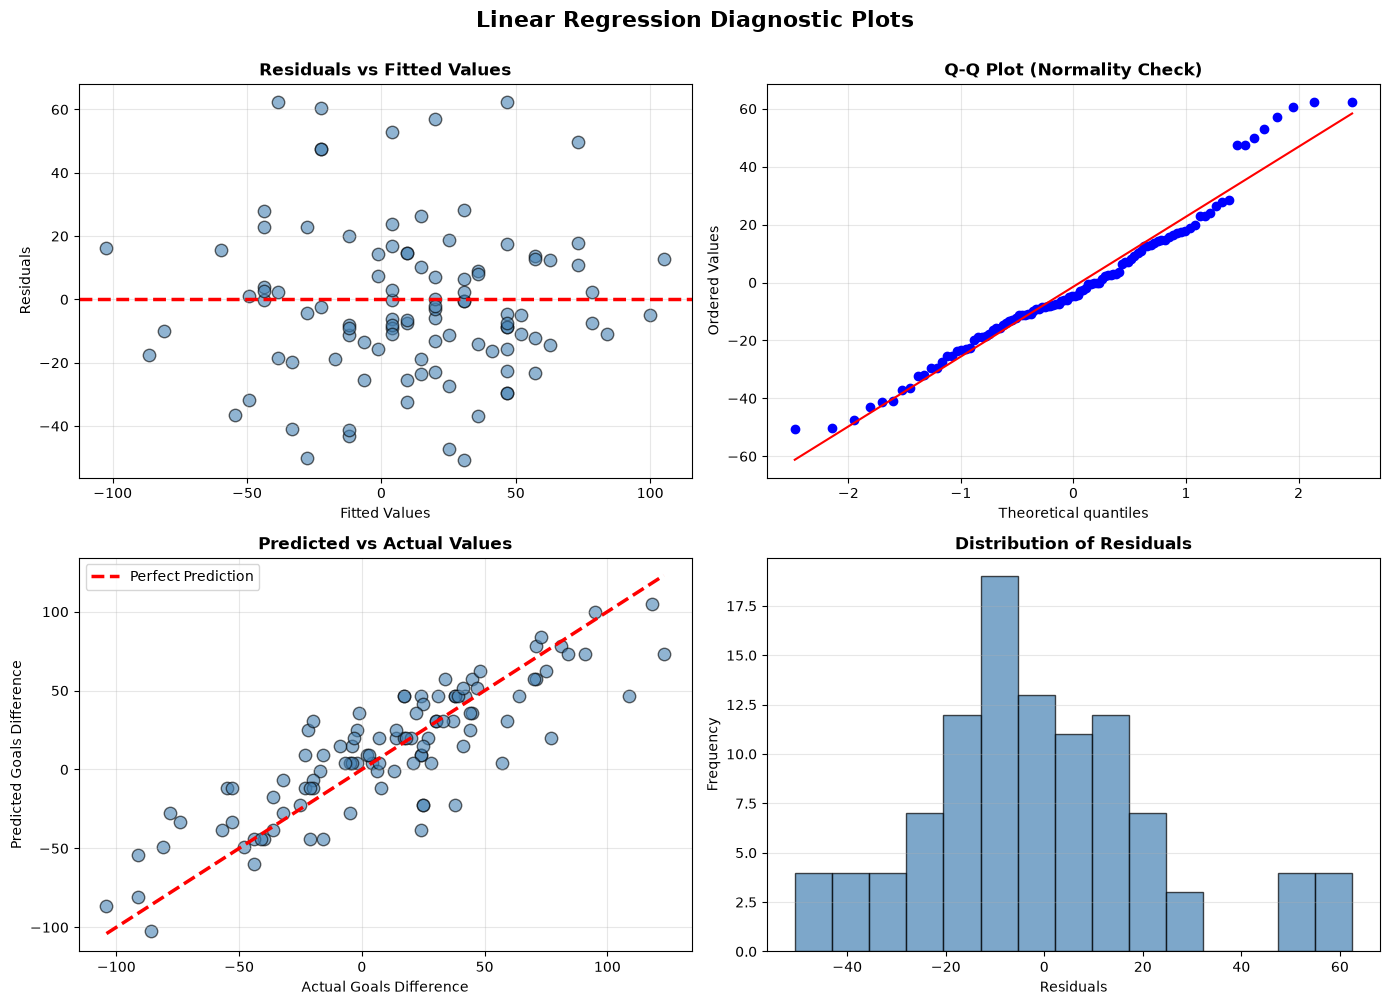

In [65]:
# Diagnostic plots to validate model 2 assumptions
from scipy import stats

# Calculate predictions and residuals on full dataset
y_pred_full2 = model2.predict(x2.reshape(-1, 1))
residuals2 = y2 - y_pred_full2.flatten()

# Create 2x2 subplot for diagnostics
fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Linear Regression Diagnostic Plots', fontsize=16, fontweight='bold', y=1.00)

# 1. Residuals vs Fitted Values
# Flatten arrays so each match corresponds to one residual
y_pred_full2 = np.asarray(y_pred_full2).ravel()
y2_flat = np.asarray(y2).ravel()
residuals2 = y2_flat - y_pred_full2

axes2[0, 0].scatter(
    y_pred_full2,
    residuals2,
    alpha=0.6,
    s=80,
    edgecolor='black',
    color='steelblue'
)
axes2[0, 0].axhline(0, color='red', linewidth=2.5, linestyle='--')
axes2[0, 0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes2[0, 0].set_xlabel('Fitted Values')
axes2[0, 0].set_ylabel('Residuals')
axes2[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot (Normality of Residuals)
stats.probplot(residuals2, dist="norm", plot=axes2[0, 1])
axes2[0, 1].set_title('Q-Q Plot (Normality Check)', fontsize=12, fontweight='bold')
axes2[0, 1].grid(True, alpha=0.3)

# 3. Predicted vs Actual
axes2[1, 0].scatter(y2, y_pred_full2, alpha=0.6, s=80, edgecolor='black', color='steelblue')
axes2[1, 0].plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'r--', linewidth=2.5, label='Perfect Prediction')
axes2[1, 0].set_title('Predicted vs Actual Values', fontsize=12, fontweight='bold')
axes2[1, 0].set_xlabel('Actual Goals Difference')
axes2[1, 0].set_ylabel('Predicted Goals Difference')
axes2[1, 0].legend()
axes2[1, 0].grid(True, alpha=0.3)

# 4. Histogram of Residuals
axes2[1, 1].hist(residuals2, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes2[1, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes2[1, 1].set_xlabel('Residuals')
axes2[1, 1].set_ylabel('Frequency')
axes2[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Print model statistics
print("\n" + "="*60)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*60)
model2.intercept_ = float(np.asarray(model2.intercept_).ravel()[0])
model2.coef_ = np.asarray(model2.coef_).ravel()

print(f"Intercept (b₀): {model2.intercept_:.4f}")
print(f"Slope (b₁): {model2.coef_[0]:.4f}")
print(f"\nR² Score (Training): {model2.score(x_train, y_train):.4f}")
print(f"R² Score (Testing): {model2.score(x_test, y_test):.4f}")
print(f"R² Score (Full Data): {model2.score(np.asarray(x2).reshape(-1, 1), np.asarray(y2).ravel()):.4f}")
print(f"\nInterpretation:")
print(f"For every additional attempt at goal (home vs away),")
print(f"the home team scores {model2.coef_[0]:.4f} more goals on average.")
print("="*60)
